# 1.Importing Necessary Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve

# 2.Dataset Loading And Pre-processing

In [2]:
file_path = "/content/creditcard.csv"
df = pd.read_csv(file_path)

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [4]:
df.shape

(59511, 31)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59511 entries, 0 to 59510
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    59511 non-null  int64  
 1   V1      59511 non-null  float64
 2   V2      59511 non-null  float64
 3   V3      59511 non-null  float64
 4   V4      59511 non-null  float64
 5   V5      59511 non-null  float64
 6   V6      59511 non-null  float64
 7   V7      59511 non-null  float64
 8   V8      59511 non-null  float64
 9   V9      59511 non-null  float64
 10  V10     59511 non-null  float64
 11  V11     59511 non-null  float64
 12  V12     59511 non-null  float64
 13  V13     59511 non-null  float64
 14  V14     59511 non-null  float64
 15  V15     59511 non-null  float64
 16  V16     59510 non-null  float64
 17  V17     59510 non-null  float64
 18  V18     59510 non-null  float64
 19  V19     59510 non-null  float64
 20  V20     59510 non-null  float64
 21  V21     59510 non-null  float64
 22

In [6]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [7]:
df[df.isnull().any(axis=1)]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
59510,48871,-2.101431,0.822359,0.342028,-0.592551,1.344203,4.774187,0.214765,1.215894,1.0241,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**2.1:-updated dataset after dropping the null values**

In [8]:
df_clean = df.dropna().reset_index(drop=True)

In [9]:
df_clean.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [11]:
df_clean.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,59510.000000,59510.000000,59510.000000,59510.000000,59510.000000,59510.000000,59510.000000,59510.000000,59510.000000,59510.000000,...,59510.000000,59510.000000,59510.000000,59510.000000,59510.000000,59510.000000,59510.000000,59510.000000,59510.000000,59510.000000
mean,31748.016669,-0.238786,-0.010206,0.688634,0.171367,-0.259829,0.102750,-0.114718,0.055167,0.063542,...,-0.027845,-0.107505,-0.039753,0.006762,0.136147,0.020146,0.002969,0.004292,95.417957,0.002722
std,13666.538897,1.866654,1.658371,1.446493,1.386079,1.394128,1.308052,1.251972,1.191471,1.183017,...,0.723975,0.637525,0.594265,0.596854,0.438683,0.498979,0.384503,0.325266,270.114653,0.052104
min,0.000000,-56.407510,-72.715728,-32.965346,-5.172595,-42.147898,-26.160506,-26.548144,-41.484823,-9.283925,...,-20.262054,-10.933144,-26.751119,-2.836627,-7.495741,-2.534330,-8.567638,-9.617915,0.000000,0.000000
25%,26156.500000,-0.993830,-0.581508,0.204127,-0.726741,-0.877852,-0.636653,-0.604522,-0.145133,-0.648072,...,-0.228746,-0.527697,-0.179894,-0.325270,-0.128046,-0.330056,-0.063393,-0.006316,7.680000,0.000000
50%,35617.000000,-0.245300,0.075679,0.779306,0.184182,-0.293987,-0.151765,-0.074182,0.061635,-0.039897,...,-0.063847,-0.082948,-0.051941,0.061830,0.174226,-0.075484,0.008921,0.022539,25.950000,0.000000
75%,42028.000000,1.155005,0.731503,1.413516,1.053209,0.278908,0.492733,0.424402,0.337119,0.735223,...,0.112591,0.307969,0.078831,0.403203,0.422293,0.297880,0.082628,0.076307,87.540000,0.000000
max,48870.000000,1.960497,18.183626,4.101716,16.715537,34.801666,22.529298,36.677268,20.007208,10.392889,...,22.614889,5.805795,17.297845,4.014444,5.525093,3.517346,11.135740,33.847808,19656.530000,1.000000


In [12]:
df_clean.shape

(59510, 31)

In [13]:
print("Before dropna:", df.shape)
print("After dropna :", df_clean.shape)

Before dropna: (59511, 31)
After dropna : (59510, 31)


In [14]:
df_clean.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [15]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59510 entries, 0 to 59509
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    59510 non-null  int64  
 1   V1      59510 non-null  float64
 2   V2      59510 non-null  float64
 3   V3      59510 non-null  float64
 4   V4      59510 non-null  float64
 5   V5      59510 non-null  float64
 6   V6      59510 non-null  float64
 7   V7      59510 non-null  float64
 8   V8      59510 non-null  float64
 9   V9      59510 non-null  float64
 10  V10     59510 non-null  float64
 11  V11     59510 non-null  float64
 12  V12     59510 non-null  float64
 13  V13     59510 non-null  float64
 14  V14     59510 non-null  float64
 15  V15     59510 non-null  float64
 16  V16     59510 non-null  float64
 17  V17     59510 non-null  float64
 18  V18     59510 non-null  float64
 19  V19     59510 non-null  float64
 20  V20     59510 non-null  float64
 21  V21     59510 non-null  float64
 22

**2.2:-Class Imbalance Visualization**

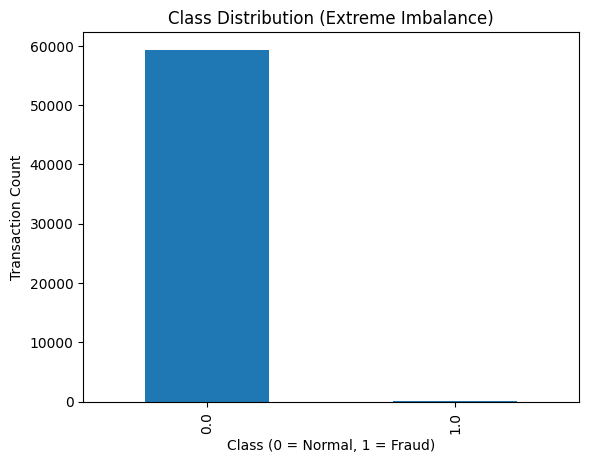

In [16]:
import matplotlib.pyplot as plt

df_clean['Class'].value_counts().plot(kind='bar')
plt.title("Class Distribution (Extreme Imbalance)")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Transaction Count")
plt.show()

**2.3:-Class Percentage**

In [17]:
df_clean['Class'].value_counts(normalize=True) * 100

,proportion
Class,
0.0,99.727777
1.0,0.272223


**2.4:-Amount Distribution**

In [18]:
df_clean['Amount'].describe()

,Amount
count,59510.000000
mean,95.417957
std,270.114653
min,0.000000
25%,7.680000
50%,25.950000
75%,87.540000
max,19656.530000


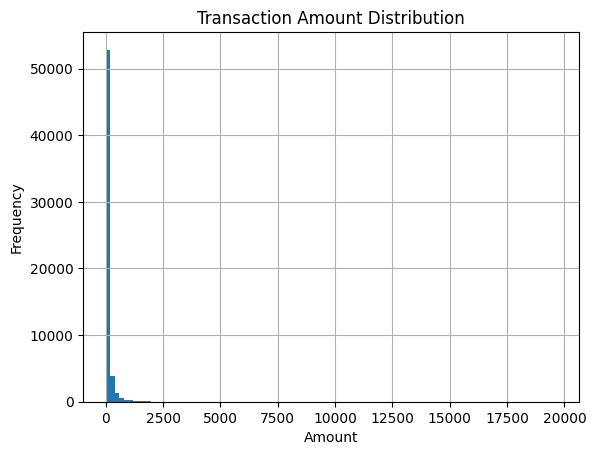

In [19]:
df_clean['Amount'].hist(bins=100)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

**2.5:-Fraud Amount Distribution**

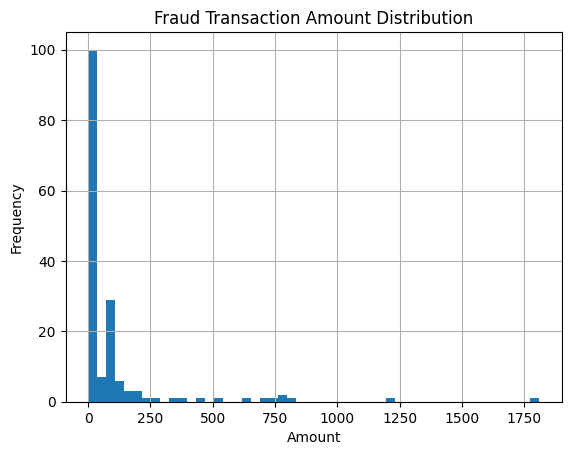

In [20]:
df_clean[df_clean['Class'] == 1]['Amount'].hist(bins=50)
plt.title("Fraud Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

**2.6:-Normal vs Fraud Amount Comparisont**

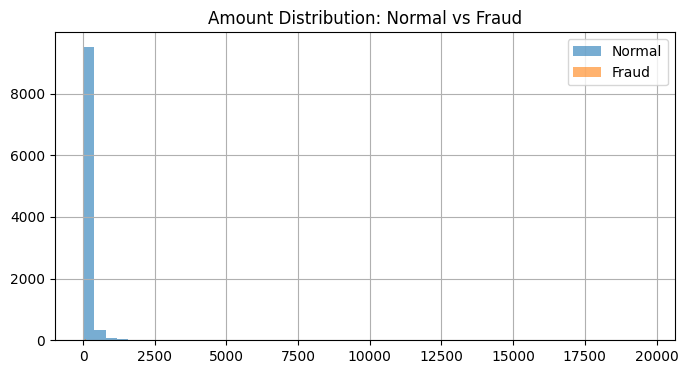

In [21]:
plt.figure(figsize=(8,4))
df_clean[df_clean['Class'] == 0]['Amount'].sample(10000).hist(bins=50, alpha=0.6, label='Normal')
df_clean[df_clean['Class'] == 1]['Amount'].hist(bins=50, alpha=0.6, label='Fraud')
plt.legend()
plt.title("Amount Distribution: Normal vs Fraud")
plt.show()

**2.7:-Time-Based Transaction Pattern**

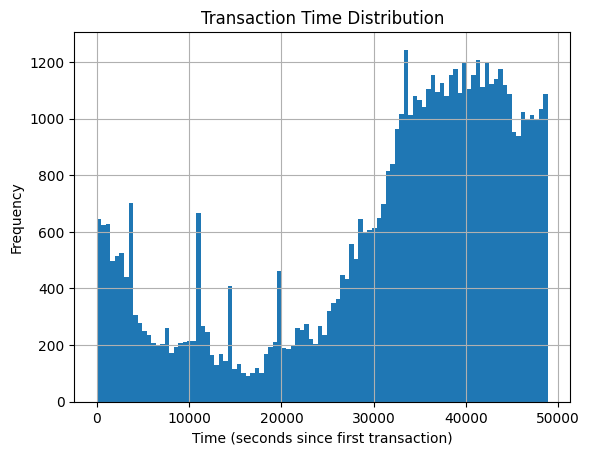

In [22]:
df_clean['Time'].hist(bins=100)
plt.title("Transaction Time Distribution")
plt.xlabel("Time (seconds since first transaction)")
plt.ylabel("Frequency")
plt.show()

# 3.Train–Test Split

In [23]:
X = df_clean.drop(columns=['Class'])
y = df_clean['Class']

In [24]:
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (59510, 30)
Label vector shape: (59510,)


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)

In [26]:
X_train_normal = X_train[y_train == 0]

# 4.Feature Scaling

In [27]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_normal)
X_test_scaled = scaler.transform(X_test)

In [28]:
print("Scaled training shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaled training shape: (41544, 30)
Scaled test shape: (17853, 30)


# 5. Model 1:
# Isolation Forest

In [29]:
iso_forest = IsolationForest(n_estimators=200,contamination=0.002,random_state=42,n_jobs=-1)
iso_forest.fit(X_train_scaled)

IsolationForest(contamination=0.002, n_estimators=200, n_jobs=-1,
                random_state=42)

In [30]:
iso_scores = iso_forest.decision_function(X_test_scaled)
iso_preds_raw = iso_forest.predict(X_test_scaled)
iso_preds = (iso_preds_raw == -1).astype(int)

In [31]:
print("Anomaly score range:", np.min(iso_scores), "to", np.max(iso_scores))
print("Predicted fraud count:", iso_preds.sum())

Anomaly score range: -0.09053546114840916 to 0.29958476131174655
Predicted fraud count: 69


In [32]:
print("Isolation Forest — Classification Report")
print(classification_report(y_test, iso_preds))

Isolation Forest — Classification Report
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     17804
         1.0       0.36      0.51      0.42        49

    accuracy                           1.00     17853
   macro avg       0.68      0.75      0.71     17853
weighted avg       1.00      1.00      1.00     17853



In [33]:
roc_auc = roc_auc_score(y_test, -iso_scores)
print("Isolation Forest ROC-AUC:", roc_auc)

Isolation Forest ROC-AUC: 0.979343096483707


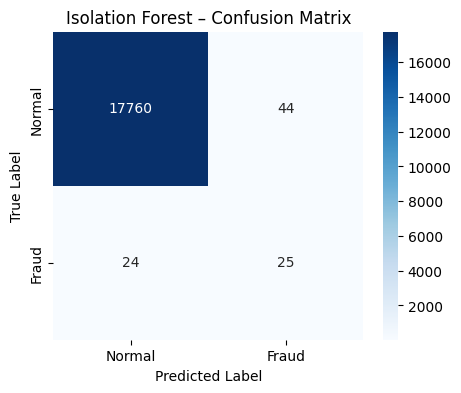

In [34]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, iso_preds)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Fraud"],
    yticklabels=["Normal", "Fraud"]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Isolation Forest – Confusion Matrix")
plt.show()


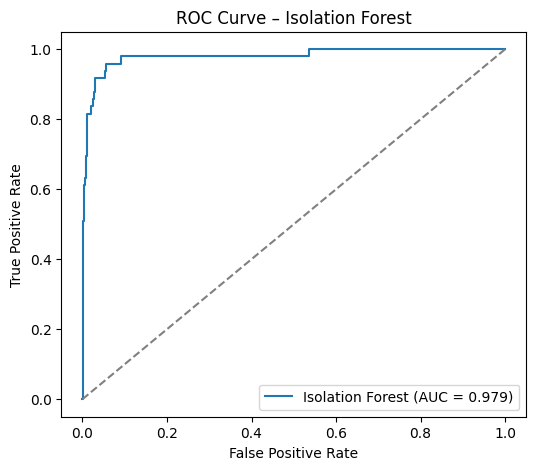

In [36]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, -iso_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"Isolation Forest (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Isolation Forest")
plt.legend()
plt.show()

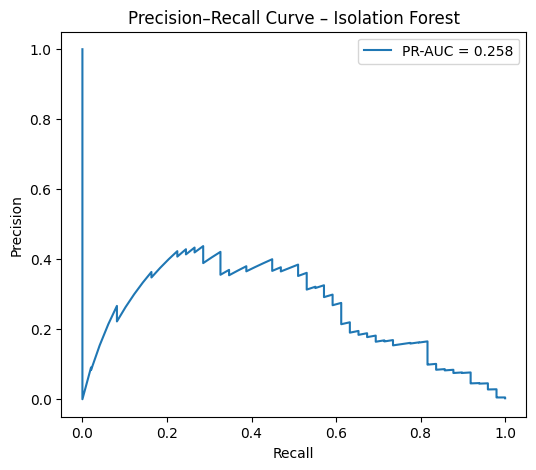

In [37]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, -iso_scores)
pr_auc = average_precision_score(y_test, -iso_scores)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve – Isolation Forest")
plt.legend()
plt.show()

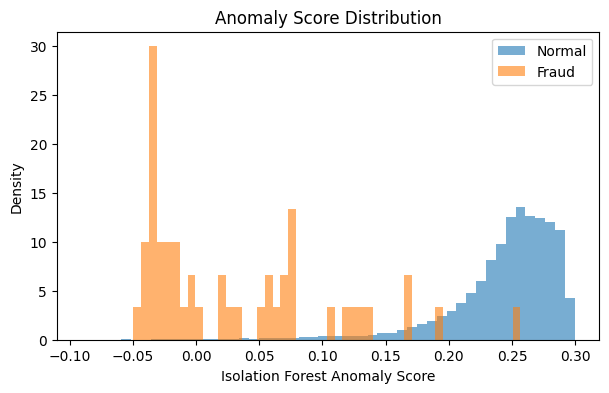

In [38]:
plt.figure(figsize=(7,4))

plt.hist(
    iso_scores[y_test == 0],
    bins=50,
    alpha=0.6,
    label="Normal",
    density=True
)

plt.hist(
    iso_scores[y_test == 1],
    bins=50,
    alpha=0.6,
    label="Fraud",
    density=True
)

plt.xlabel("Isolation Forest Anomaly Score")
plt.ylabel("Density")
plt.title("Anomaly Score Distribution")
plt.legend()
plt.show()

# 6. Model 2:-
# One-Class SVM (Secondary Anomaly Detector)

In [39]:
ocsvm = OneClassSVM(kernel='rbf',nu=0.002,gamma='scale')
ocsvm.fit(X_train_scaled)

OneClassSVM(nu=0.002)

In [40]:
svm_scores = ocsvm.decision_function(X_test_scaled)
svm_preds_raw = ocsvm.predict(X_test_scaled)
svm_preds = (svm_preds_raw == -1).astype(int)

In [41]:
print("SVM score range:", np.min(svm_scores), "to", np.max(svm_scores))
print("Predicted fraud count:", svm_preds.sum())

SVM score range: -0.2769005074110953 to 0.5222768756688936
Predicted fraud count: 376


In [42]:
print("One-Class SVM — Classification Report")
print(classification_report(y_test, svm_preds))

One-Class SVM — Classification Report
              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99     17804
         1.0       0.12      0.94      0.22        49

    accuracy                           0.98     17853
   macro avg       0.56      0.96      0.60     17853
weighted avg       1.00      0.98      0.99     17853



In [43]:
roc_auc_svm = roc_auc_score(y_test, -svm_scores)
print("One-Class SVM ROC-AUC:", roc_auc_svm)

One-Class SVM ROC-AUC: 0.9830220450345944


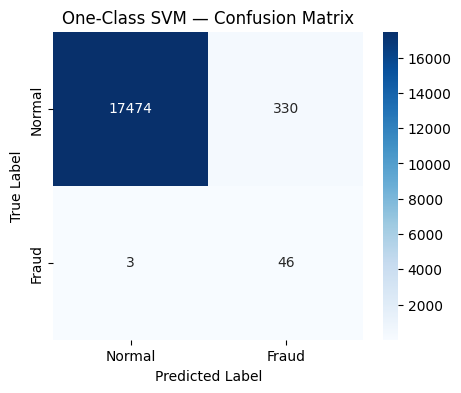

In [44]:
cm_svm = confusion_matrix(y_test, svm_preds)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Fraud"],
    yticklabels=["Normal", "Fraud"]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("One-Class SVM — Confusion Matrix")
plt.show()

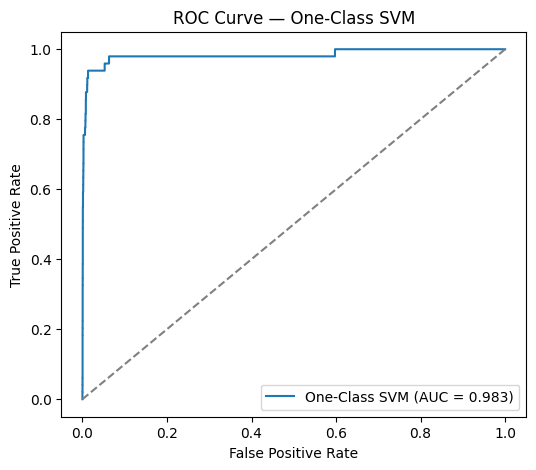

In [45]:
fpr_svm, tpr_svm, _ = roc_curve(y_test, -svm_scores)
roc_auc_svm = auc(fpr_svm, tpr_svm)

plt.figure(figsize=(6,5))
plt.plot(fpr_svm, tpr_svm, label=f"One-Class SVM (AUC = {roc_auc_svm:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — One-Class SVM")
plt.legend()
plt.show()

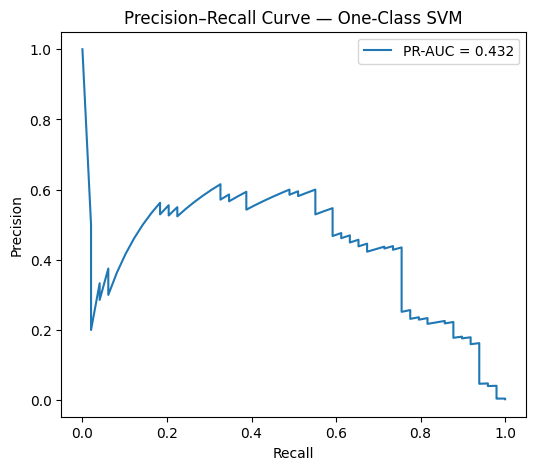

In [46]:
precision_svm, recall_svm, _ = precision_recall_curve(y_test, -svm_scores)
pr_auc_svm = average_precision_score(y_test, -svm_scores)

plt.figure(figsize=(6,5))
plt.plot(recall_svm, precision_svm, label=f"PR-AUC = {pr_auc_svm:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve — One-Class SVM")
plt.legend()
plt.show()

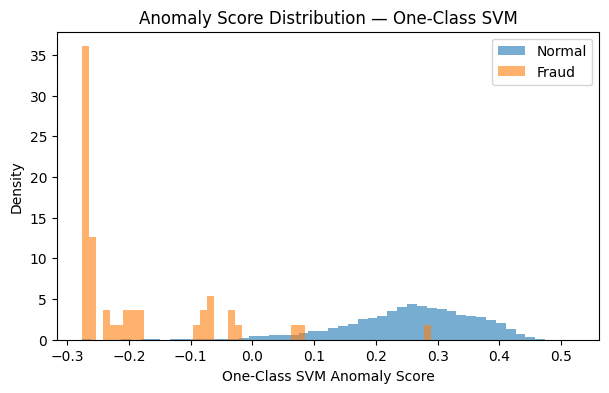

In [47]:
plt.figure(figsize=(7,4))

plt.hist(
    svm_scores[y_test == 0],
    bins=50,
    alpha=0.6,
    label="Normal",
    density=True
)

plt.hist(
    svm_scores[y_test == 1],
    bins=50,
    alpha=0.6,
    label="Fraud",
    density=True
)

plt.xlabel("One-Class SVM Anomaly Score")
plt.ylabel("Density")
plt.title("Anomaly Score Distribution — One-Class SVM")
plt.legend()
plt.show()

# 7 Model 3:-
# Local Outlier Factor (LOF — Novelty Detection)

In [48]:
novelty=True

In [49]:
lof = LocalOutlierFactor(n_neighbors=20,contamination=0.002,novelty=True)
lof.fit(X_train_scaled)

LocalOutlierFactor(contamination=0.002, novelty=True)

In [50]:
lof_scores = lof.decision_function(X_test_scaled)
lof_preds_raw = lof.predict(X_test_scaled)
lof_preds = (lof_preds_raw == -1).astype(int)

In [51]:
print("LOF anomaly score range:", np.min(lof_scores), "to", np.max(lof_scores))
print("Predicted fraud count:", lof_preds.sum())

LOF anomaly score range: -566.0441015704389 to 2.7061321888857854
Predicted fraud count: 48


In [52]:
print("Local Outlier Factor — Classification Report")
print(classification_report(y_test, lof_preds))

Local Outlier Factor — Classification Report
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     17804
         1.0       0.19      0.18      0.19        49

    accuracy                           1.00     17853
   macro avg       0.59      0.59      0.59     17853
weighted avg       1.00      1.00      1.00     17853



In [53]:
roc_auc_lof = roc_auc_score(y_test, -lof_scores)
print("LOF ROC-AUC:", roc_auc_lof)

LOF ROC-AUC: 0.8607513101848243


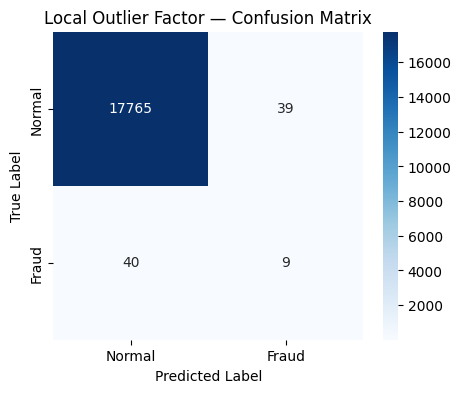

In [54]:
cm_lof = confusion_matrix(y_test, lof_preds)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_lof,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Fraud"],
    yticklabels=["Normal", "Fraud"]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Local Outlier Factor — Confusion Matrix")
plt.show()

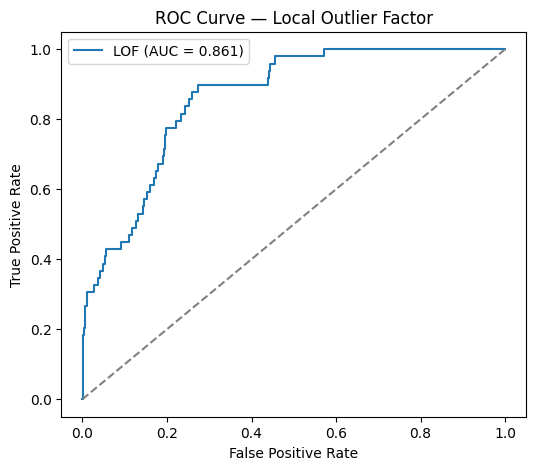

In [55]:
fpr_lof, tpr_lof, _ = roc_curve(y_test, -lof_scores)
roc_auc_lof = auc(fpr_lof, tpr_lof)

plt.figure(figsize=(6,5))
plt.plot(fpr_lof, tpr_lof, label=f"LOF (AUC = {roc_auc_lof:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Local Outlier Factor")
plt.legend()
plt.show()

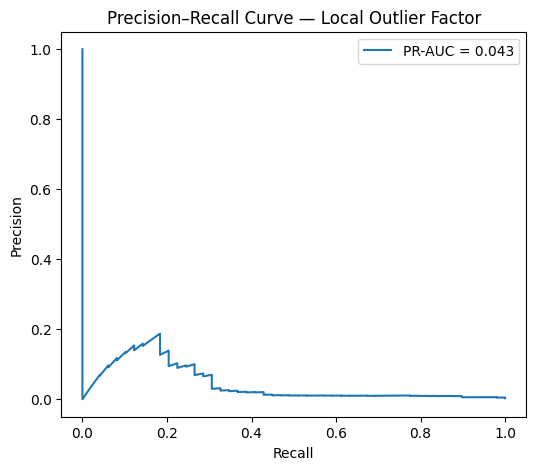

In [56]:
precision_lof, recall_lof, _ = precision_recall_curve(y_test, -lof_scores)
pr_auc_lof = average_precision_score(y_test, -lof_scores)

plt.figure(figsize=(6,5))
plt.plot(recall_lof, precision_lof, label=f"PR-AUC = {pr_auc_lof:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve — Local Outlier Factor")
plt.legend()
plt.show()

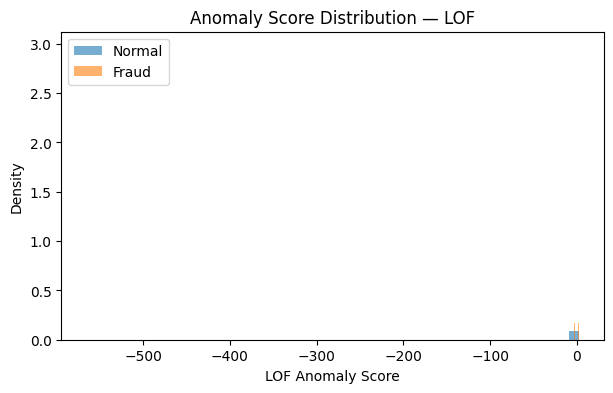

In [57]:
plt.figure(figsize=(7,4))

plt.hist(
    lof_scores[y_test == 0],
    bins=50,
    alpha=0.6,
    label="Normal",
    density=True
)

plt.hist(
    lof_scores[y_test == 1],
    bins=50,
    alpha=0.6,
    label="Fraud",
    density=True
)

plt.xlabel("LOF Anomaly Score")
plt.ylabel("Density")
plt.title("Anomaly Score Distribution — LOF")
plt.legend()
plt.show()

# 8. Model Comparison (Isolation Forest vs One-Class SVM vs LOF)

In [58]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

comparison_results = []

def add_results(model_name, y_true, y_pred, scores):
    comparison_results.append({
        "Model": model_name,
        "Precision (Fraud)": precision_score(y_true, y_pred),
        "Recall (Fraud)": recall_score(y_true, y_pred),
        "F1-score (Fraud)": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, -scores),
        "PR-AUC": average_precision_score(y_true, -scores)
    })

add_results("Isolation Forest", y_test, iso_preds, iso_scores)
add_results("One-Class SVM", y_test, svm_preds, svm_scores)
add_results("LOF", y_test, lof_preds, lof_scores)

In [59]:
comparison_df = pd.DataFrame(comparison_results)
comparison_df

,Model,Precision (Fraud),Recall (Fraud),F1-score (Fraud),ROC-AUC,PR-AUC
0,Isolation Forest,0.362319,0.510204,0.423729,0.979343,0.257759
1,One-Class SVM,0.122340,0.938776,0.216471,0.983022,0.432446
2,LOF,0.187500,0.183673,0.185567,0.860751,0.043226


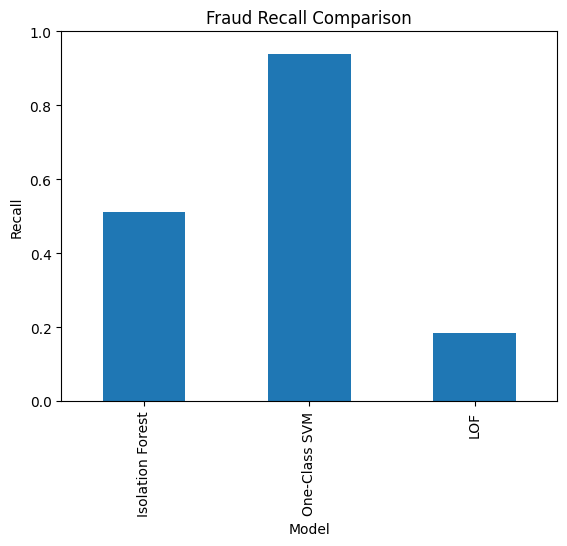

In [60]:
comparison_df.set_index("Model")["Recall (Fraud)"].plot(
    kind="bar",
    title="Fraud Recall Comparison",
    ylabel="Recall",
    ylim=(0,1)
)
plt.show()

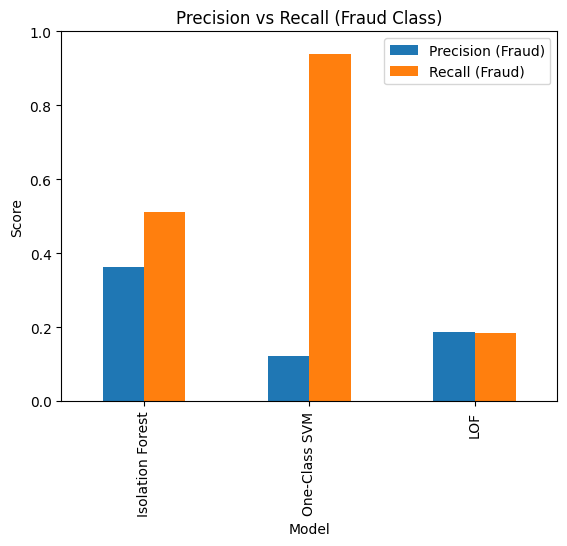

In [61]:
comparison_df.set_index("Model")[["Precision (Fraud)", "Recall (Fraud)"]].plot(
    kind="bar",
    title="Precision vs Recall (Fraud Class)",
    ylabel="Score",
    ylim=(0,1)
)
plt.show()

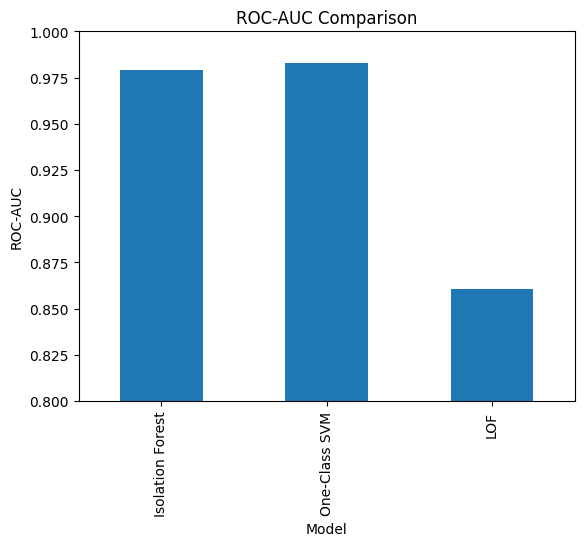

In [62]:
comparison_df.set_index("Model")["ROC-AUC"].plot(
    kind="bar",
    title="ROC-AUC Comparison",
    ylabel="ROC-AUC",
    ylim=(0.8,1)
)
plt.show()

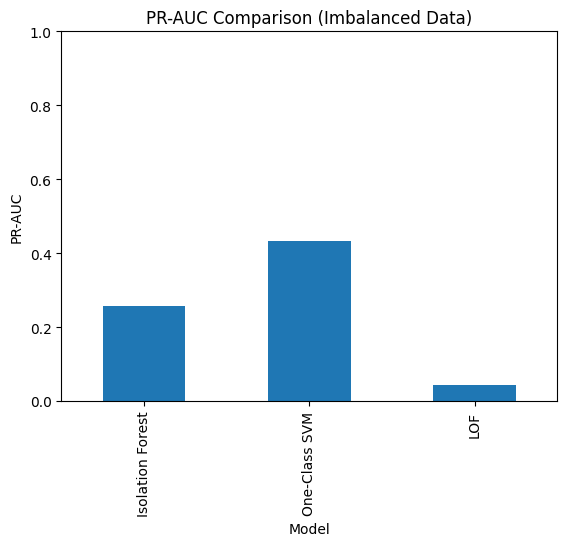

In [63]:
comparison_df.set_index("Model")["PR-AUC"].plot(
    kind="bar",
    title="PR-AUC Comparison (Imbalanced Data)",
    ylabel="PR-AUC",
    ylim=(0,1)
)
plt.show()

# 9. Real-Time Fraud Detection Simulation

In [64]:
alert_threshold = np.percentile(iso_scores, 1)
alert_threshold

np.float64(0.060428499508055324)

In [65]:
def get_alert_level(score, threshold):
    if score < threshold:
        return "HIGH"
    elif score < threshold * 1.2:
        return "MEDIUM"
    else:
        return "LOW"

In [66]:
realtime_logs = []

for idx in range(len(X_test_scaled)):
    txn_features = X_test_scaled[idx].reshape(1, -1)

    # Generate risk score
    risk_score = iso_forest.decision_function(txn_features)[0]

    # Determine alert level
    alert_level = get_alert_level(risk_score, alert_threshold)

    realtime_logs.append({
        "transaction_id": idx,
        "risk_score": risk_score,
        "alert_level": alert_level,
        "actual_label": y_test.iloc[idx]
    })

In [67]:
realtime_df = pd.DataFrame(realtime_logs)
realtime_df.head(10)

,transaction_id,risk_score,alert_level,actual_label
0,0,0.209798,LOW,0.0
1,1,0.235150,LOW,0.0
2,2,0.284295,LOW,0.0
3,3,0.272194,LOW,0.0
4,4,0.248867,LOW,0.0
5,5,0.213765,LOW,0.0
6,6,0.280933,LOW,0.0
7,7,0.253214,LOW,0.0
8,8,0.273079,LOW,0.0
9,9,0.234961,LOW,0.0


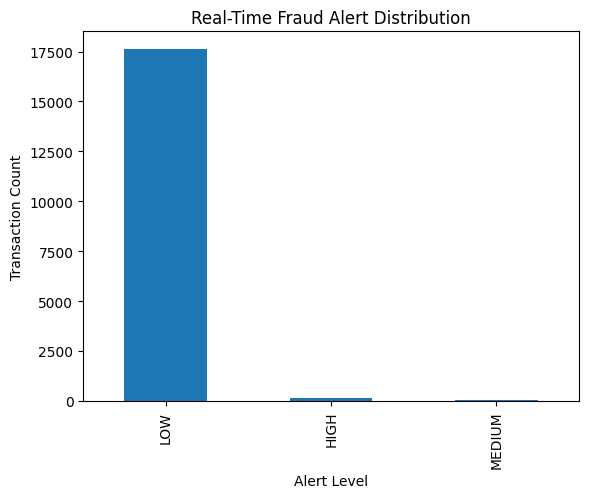

In [68]:
realtime_df['alert_level'].value_counts().plot(
    kind="bar",
    title="Real-Time Fraud Alert Distribution"
)
plt.xlabel("Alert Level")
plt.ylabel("Transaction Count")
plt.show()

In [69]:
pd.crosstab(
    realtime_df['alert_level'],
    realtime_df['actual_label'],
    rownames=['Alert Level'],
    colnames=['Actual Class']
)

Actual Class,0.0,1.0
Alert Level,,
HIGH,146,33
LOW,17609,13
MEDIUM,49,3


In [70]:
missed_frauds = realtime_df[
    (realtime_df['actual_label'] == 1) &
    (realtime_df['alert_level'] == "LOW")
]

missed_frauds.head()

,transaction_id,risk_score,alert_level,actual_label
534,534,0.168614,LOW,1.0
567,567,0.256581,LOW,1.0
2063,2063,0.190851,LOW,1.0
2764,2764,0.075205,LOW,1.0
6616,6616,0.167159,LOW,1.0


# 10. 📊 FINAL DEMO DASHBOARD — FRAUD DETECTION SYSTEM

In [71]:
total_txns = len(realtime_df)
total_frauds = realtime_df['actual_label'].sum()
caught_frauds = realtime_df[
    (realtime_df['actual_label'] == 1) &
    (realtime_df['alert_level'] != "LOW")
].shape[0]

missed_frauds = total_frauds - caught_frauds
recall_pct = caught_frauds / total_frauds * 100

summary_df = pd.DataFrame({
    "Metric": [
        "Total Transactions",
        "Total Frauds",
        "Frauds Caught",
        "Frauds Missed",
        "Fraud Recall (%)"
    ],
    "Value": [
        total_txns,
        total_frauds,
        caught_frauds,
        missed_frauds,
        f"{recall_pct:.2f}%"
    ]
})

summary_df

,Metric,Value
0,Total Transactions,17853
1,Total Frauds,49.0
2,Frauds Caught,36
3,Frauds Missed,13.0
4,Fraud Recall (%),73.47%


In [72]:
from IPython.display import display

display(summary_df.style.set_properties(**{
    'font-size': '14pt',
    'text-align': 'center'
}))

,Metric,Value
0,Total Transactions,17853
1,Total Frauds,49.000000
2,Frauds Caught,36
3,Frauds Missed,13.000000
4,Fraud Recall (%),73.47%


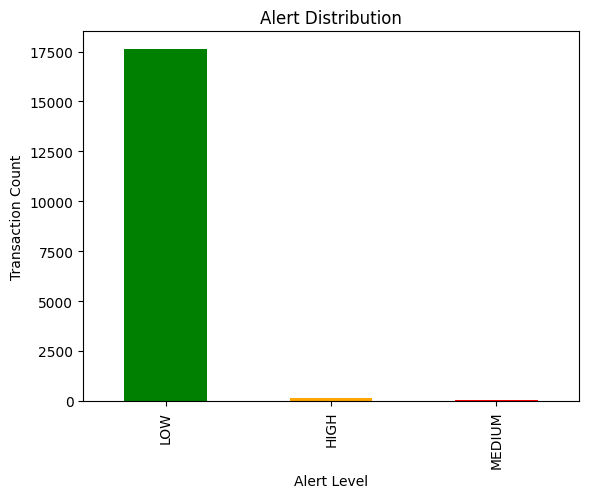

In [73]:
import matplotlib.pyplot as plt

realtime_df['alert_level'].value_counts().plot(
    kind="bar",
    title="Alert Distribution",
    color=["green", "orange", "red"]
)

plt.xlabel("Alert Level")
plt.ylabel("Transaction Count")
plt.show()

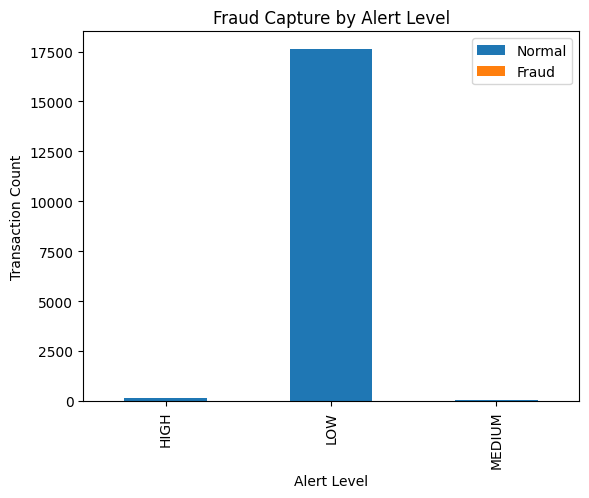

In [74]:
pd.crosstab(
    realtime_df['alert_level'],
    realtime_df['actual_label']
).plot(
    kind="bar",
    stacked=True,
    title="Fraud Capture by Alert Level"
)

plt.xlabel("Alert Level")
plt.ylabel("Transaction Count")
plt.legend(["Normal", "Fraud"])
plt.show()

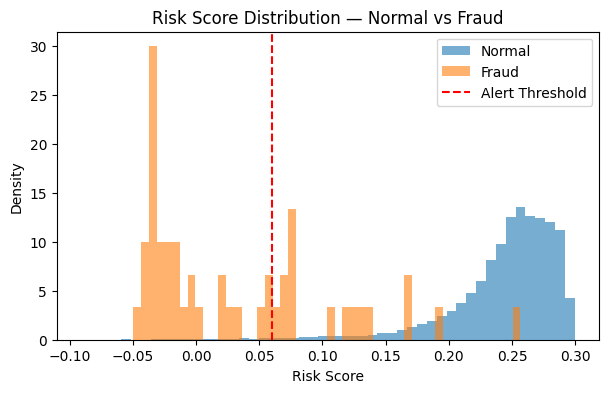

In [75]:
plt.figure(figsize=(7,4))

plt.hist(
    realtime_df[realtime_df['actual_label'] == 0]['risk_score'],
    bins=50,
    alpha=0.6,
    label="Normal",
    density=True
)

plt.hist(
    realtime_df[realtime_df['actual_label'] == 1]['risk_score'],
    bins=50,
    alpha=0.6,
    label="Fraud",
    density=True
)

plt.axvline(alert_threshold, color='red', linestyle='--', label='Alert Threshold')

plt.xlabel("Risk Score")
plt.ylabel("Density")
plt.title("Risk Score Distribution — Normal vs Fraud")
plt.legend()
plt.show()

In [76]:
import ipywidgets as widgets

def simulate_threshold(percentile):
    threshold = np.percentile(iso_scores, percentile)

    alerts = []
    for score in iso_scores:
        if score < threshold:
            alerts.append("HIGH")
        elif score < threshold * 1.2:
            alerts.append("MEDIUM")
        else:
            alerts.append("LOW")

    temp_df = realtime_df.copy()
    temp_df['alert_level'] = alerts

    caught = temp_df[
        (temp_df['actual_label'] == 1) &
        (temp_df['alert_level'] != "LOW")
    ].shape[0]

    recall = caught / total_frauds * 100

    print(f"Threshold Percentile: {percentile}%")
    print(f"Fraud Recall: {recall:.2f}%")
    print(temp_df['alert_level'].value_counts())

widgets.interact(
    simulate_threshold,
    percentile=widgets.FloatSlider(min=0.2, max=5, step=0.2, value=1)
)

interactive(children=(FloatSlider(value=1.0, description='percentile', max=5.0, min=0.2, step=0.2), Output()),…

<function __main__.simulate_threshold(percentile)>

# 11. GRADIO FRAUD DETECTION DASHBOARD

In [77]:
!pip install gradio --quiet -q

In [78]:
import gradio as gr

In [79]:
def fraud_dashboard(threshold_percentile):
    # Compute threshold
    threshold = np.percentile(iso_scores, threshold_percentile)

    # Generate alert levels
    alert_levels = []
    for score in iso_scores:
        if score < threshold:
            alert_levels.append("HIGH")
        elif score < threshold * 1.2:
            alert_levels.append("MEDIUM")
        else:
            alert_levels.append("LOW")

    # Build temp dataframe
    temp_df = pd.DataFrame({
        "risk_score": iso_scores,
        "actual_label": y_test.values,
        "alert_level": alert_levels
    })

    # Metrics
    total_frauds = temp_df["actual_label"].sum()
    caught_frauds = temp_df[
        (temp_df["actual_label"] == 1) &
        (temp_df["alert_level"] != "LOW")
    ].shape[0]

    recall = (caught_frauds / total_frauds) * 100 if total_frauds > 0 else 0
    total_alerts = (temp_df["alert_level"] != "LOW").sum()

    # Alert distribution
    alert_dist = temp_df["alert_level"].value_counts().reset_index()
    alert_dist.columns = ["Alert Level", "Count"]

    # Fraud capture table
    fraud_capture = pd.crosstab(
        temp_df["alert_level"],
        temp_df["actual_label"]
    ).reset_index()

    # Risk score distribution plot
    fig, ax = plt.subplots(figsize=(6,4))
    ax.hist(
        temp_df[temp_df["actual_label"] == 0]["risk_score"],
        bins=50, alpha=0.6, label="Normal", density=True
    )
    ax.hist(
        temp_df[temp_df["actual_label"] == 1]["risk_score"],
        bins=50, alpha=0.6, label="Fraud", density=True
    )
    ax.axvline(threshold, color="red", linestyle="--", label="Threshold")
    ax.set_title("Risk Score Distribution")
    ax.set_xlabel("Risk Score")
    ax.legend()
    plt.tight_layout()

    summary_text = (
        f"Threshold Percentile: {threshold_percentile}%\n"
        f"Fraud Recall: {recall:.2f}%\n"
        f"Total Alerts Triggered: {total_alerts}\n"
        f"Frauds Caught: {caught_frauds} / {int(total_frauds)}"
    )

    return summary_text, alert_dist, fraud_capture, fig

In [80]:
dashboard = gr.Interface(
    fn=fraud_dashboard,
    inputs=gr.Slider(
        minimum=0.2,
        maximum=5,
        step=0.2,
        value=1,
        label="Alert Threshold Percentile (Lower = More Aggressive)"
    ),
    outputs=[
        gr.Textbox(label="Fraud Detection Summary"),
        gr.Dataframe(label="Alert Distribution"),
        gr.Dataframe(label="Fraud Capture by Alert Level"),
        gr.Plot(label="Risk Score Distribution")
    ],
    title="💳 Real-Time Fraud Detection Dashboard",
    description=(
        "Interactive fraud monitoring dashboard using anomaly detection.\n"
        "Adjust the threshold to observe the trade-off between fraud recall and alert volume."
    )
)

In [81]:
dashboard.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://243a7da4832c825cf9.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# 12. 🧠 DASHBOARD ENHANCEMENT PLAN

In [82]:
model_scores = {
    "Isolation Forest": iso_scores,
    "One-Class SVM": svm_scores,
    "LOF": lof_scores
}

In [86]:
def fraud_dashboard(model_name, threshold_percentile):
    # Select scores based on model
    scores = model_scores[model_name]

    # Threshold
    threshold = np.percentile(scores, threshold_percentile)

    # Alert logic
    alert_levels = []
    for score in scores:
        if score < threshold:
            alert_levels.append("HIGH")
        elif score < threshold * 1.2:
            alert_levels.append("MEDIUM")
        else:
            alert_levels.append("LOW")

    # Build dataframe
    temp_df = pd.DataFrame({
        "risk_score": scores,
        "actual_label": y_test.values,
        "alert_level": alert_levels
    })

    # KPIs
    total_transactions = len(scores)
    total_frauds = temp_df["actual_label"].sum()

    caught_frauds = temp_df[
        (temp_df["actual_label"] == 1) &
        (temp_df["alert_level"] != "LOW")
    ].shape[0]

    missed_frauds = total_frauds - caught_frauds
    recall = (caught_frauds / total_frauds) * 100 if total_frauds > 0 else 0

    summary = (
        f"📊 KPIs\n"
        f"- Model: {model_name}\n"
        f"- Total Transactions: {total_transactions}\n"
        f"- Total Frauds: {int(total_frauds)}\n"
        f"- Frauds Caught: {caught_frauds}\n"
        f"- Frauds Missed: {int(missed_frauds)}\n"
        f"- Fraud Recall: {recall:.2f}%\n"
        f"- Threshold Percentile: {threshold_percentile}%"
    )

    # Tables
    alert_dist = temp_df["alert_level"].value_counts().reset_index()
    alert_dist.columns = ["Alert Level", "Count"]

    fraud_capture = pd.crosstab(
        temp_df["alert_level"],
        temp_df["actual_label"]
    ).reset_index()

    return summary, alert_dist, fraud_capture

In [87]:
dashboard = gr.Interface(
    fn=fraud_dashboard,
    inputs=[
        gr.Dropdown(
            choices=list(model_scores.keys()),
            value="Isolation Forest",
            label="Select Fraud Detection Model"
        ),
        gr.Slider(
            minimum=0.2,
            maximum=5,
            step=0.2,
            value=1,
            label="Alert Threshold Percentile"
        )
    ],
    outputs=[
        gr.Textbox(label="System KPIs"),
        gr.Dataframe(label="Alert Distribution"),
        gr.Dataframe(label="Fraud Capture Table")
    ],
    title="💳 Fraud Detection Control Panel",
    description="Interactive dashboard for anomaly-based fraud detection"
)

In [88]:
dashboard.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4c5a48d1b147cdeedc.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
